# Predicting U.S. Video Game Sales: Linear & Logistic Regression (2004–2010)

**Shaurya Ghai, Granth Bangard**

Part 3 of 3 — Predictive Modeling

## 1. Introduction

### Dataset
This notebook continues analysis of the Video Games Sales dataset: 1,770 commercially notable titles released in the U.S. between 2004–2010, curated by Dr. Joe Cox (University of Portsmouth Research Portal).

### Research Questions
1. **Linear Regression:** What is the relationship between a game's release year and its U.S. sales, after controlling for online features, perspective type, and console platform? How does this model perform on unseen data?
2. **Logistic Regression:** How do release year, online features, and perspective type relate to the probability of a game being a blockbuster (selling over 1 million copies)? How does a classifier built on this model perform?

### Response Variables
- *Linear regression:* `US Sales (millions)` — continuous, measuring commercial performance
- *Logistic regression:* `Block1` — binary indicator of blockbuster status (sales > 1M)

### Contextual Importance
Understanding what drives video game sales helps publishers and developers make informed decisions about game design and platform strategy. A regression model also lets us identify which features are statistically associated with higher commercial performance, and how much of that variation we can actually explain.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import root_mean_squared_error

df = pd.read_csv('video_games.csv', encoding='unicode-escape')
df = df.rename(columns={'US Sales (millions)': 'US_Sales'})
print(df.shape)
df.head()

(1770, 166)


,Console,Title,US_Sales,Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


## 2. Linear Regression: Predicting U.S. Sales

### Research Question
What is the relationship between a game's release year and its U.S. sales, after controlling for online features, perspective type, and console platform?

In [2]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print('Training set:', train_df.shape)
print('Test set:', test_df.shape)

Training set: (1416, 166)
Test set: (354, 166)


80/20 train-test split with random_state=42 for reproducibility.

In [3]:
model = smf.ols(
    'US_Sales ~ YearReleased + Online + FirstPerson + ThirdPerson + C(Console)',
    data=train_df
).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               US_Sales   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     5.847
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.26e-07
Time:                        13:48:05   Log-Likelihood:                -2059.7
No. Observations:                1416   AIC:                             4137.
Df Residuals:                    1407   BIC:                             4185.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      29.3605     46.100      0.637      0.524     -61.071     119.792
C(Console)[T.Nintendo Wii]      0.2685      0.093      2.880      0.004       0.086       0.451
C(Console)[T.PlayStation 3]    -0.0773      0.101     -0.767      0.443      -0.275       0.121
C(Console)[T.Sony PSP]         -0.3179      0.093     -3.424      0.001      -0.500      -0.136
C(Console)[T.X360]              0.0169      0.091      0.187      0.852      -0.161       0.195
YearReleased                   -0.0145      0.023     -0.629      0.529      -0.060       0.031
Online                          0.2365      0.067      3.515      0.000       0.105       0.368
FirstPerson                     0.0965      0.068      1.417      0.157      -0.037       0.230
ThirdPerson                     0.0763      0.068      1.118      0.264      -0.058       0.210
==============================================================================
Omnibus:                     1777.506   Durbin-Watson:                   2.006
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           219521.378
Skew:                           6.704   Prob(JB):                         0.00
Kurtosis:                      62.506   Cond. No.                     3.35e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.35e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Fitted equation** (Console = Nintendo DS as baseline):

ŷ = 29.36 + (−0.0145)(YearReleased) + (0.2365)(Online) + (0.0965)(FirstPerson) + (0.0763)(ThirdPerson)

After controlling for online features, perspective type, and console platform, each additional year is associated with a decrease of approximately 0.0145 million copies in U.S. sales on average.

In [4]:
ci = model.conf_int(alpha=0.05).loc['YearReleased']
print(f'95% CI for YearReleased slope: [{ci[0]:.4f}, {ci[1]:.4f}]')

95% CI for YearReleased slope: [-0.0595, 0.0306]


We are 95% confident that in the population, after controlling for the other predictors, each additional year is associated with a change in U.S. sales between −0.0595 and +0.0306 million copies. Since this interval contains zero, **we cannot conclude a statistically significant relationship** between release year and U.S. sales in the population.

### Checking Model Assumptions

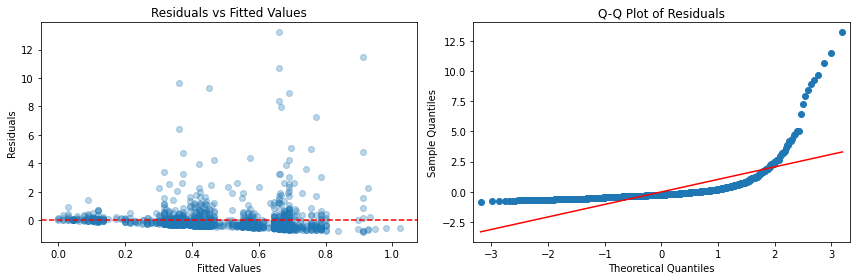

In [5]:
fitted_vals = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted_vals, residuals, alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

**Condition check:**
- *Equal variance:* Residuals show a clear fan shape — variance increases at higher fitted values. Equal variance condition is **not well supported.**
- *Normality:* Q-Q plot deviates heavily in the upper tail. Normality condition is **not well supported.**

The confidence intervals should be interpreted cautiously given these violations.

In [6]:
print('R-squared (train):', round(model.rsquared, 4))
print('RMSE (test):', round(root_mean_squared_error(test_df['US_Sales'], model.predict(test_df)), 4))

R-squared (train): 0.0322
RMSE (test): 1.0947


**Model performance:**
- R² = 0.032 — the model explains only about 3.2% of variability in U.S. sales
- RMSE = 1.09 million copies on test data — predictions are off by ~1.09M on average

Given that most games sell under 1M copies, this is a high error rate. The selected predictors (release year, online features, perspective, console) do not explain what drives sales — factors like franchise recognition, marketing budgets, and critic reviews likely matter far more.

## 3. Logistic Regression: Predicting Blockbuster Status

### Research Question
How do release year, online features, and perspective type relate to the probability of a game being a blockbuster (> 1M U.S. copies sold)?

In [7]:
logit_model = smf.logit(
    'Block1 ~ YearReleased + Online + FirstPerson + ThirdPerson',
    data=train_df
).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.328904
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Block1   No. Observations:                 1416
Model:                          Logit   Df Residuals:                     1411
Method:                           MLE   Df Model:                            4
Date:                Fri, 29 May 2026   Pseudo R-squ.:                 0.02670
Time:                        13:48:08   Log-Likelihood:                -465.73
converged:                       True   LL-Null:                       -478.50
Covariance Type:            nonrobust   LLR p-value:                 3.904e-05
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -153.6504    129.451     -1.187      0.235    -407.370     100.069
YearReleased     0.0751      0.064      1.164      0.244      -0.051       0.201
Online           0.4004      0.179      2.241      0.025       0.050       0.751
FirstPerson      0.6806      0.194      3.514      0.000       0.301       1.060
ThirdPerson      0.6076      0.232      2.614      0.009       0.152       1.063
================================================================================
"""

All four predictors show positive associations with the log-odds of blockbuster status. Games with online features, first-person, or third-person perspectives all have higher estimated log-odds of reaching blockbuster status. Release year has a positive but very small coefficient.

In [8]:
print('Pseudo R-squared:', round(logit_model.prsquared, 4))

preds_train = logit_model.predict(train_df)
auc_train = roc_auc_score(train_df['Block1'], preds_train)
print('AUC (train):', round(auc_train, 4))

Pseudo R-squared: 0.0267
AUC (train): 0.6154


- **Pseudo R² = 0.0267** — model explains about 2.67% of variation in blockbuster status
- **AUC = 0.6154** — performs slightly better than random chance (0.5) at distinguishing blockbusters from non-blockbusters

Modest but nonzero signal in the data.

In [9]:
preds_test = logit_model.predict(test_df)
preds_class = (preds_test >= 0.10).astype(int)

cm = confusion_matrix(test_df['Block1'], preds_class)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(test_df['Block1'], preds_class)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print('Confusion Matrix:')
print(cm)
print(f'Accuracy:    {acc:.4f}')
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

Confusion Matrix:
[[188 131]
 [ 13  22]]
Accuracy:    0.5932
Sensitivity: 0.6286
Specificity: 0.5893


### Threshold Choice
The default threshold of 0.5 produced sensitivity = 0 (classified no game as a blockbuster) because only ~10% of games are blockbusters — a heavily imbalanced dataset. Lowering the threshold to **0.10** allows the model to identify more potential blockbusters.

**In this context, false negatives are the more costly error** — predicting a game won't be a blockbuster when it will leads to underinvestment in marketing and distribution for a high-potential title. We therefore prioritized sensitivity.

**Results at threshold = 0.10:**
- Accuracy: 59.3%
- Sensitivity: 62.9% — correctly identifies ~63% of actual blockbusters
- Specificity: 58.9%

Meaningful improvement over a 0.5 threshold, though the model still misses ~37% of blockbusters. Performance is modest overall.

## 4. Conclusion

### Summary
We fit two regression models to predict U.S. video game sales from 2004–2010:

**Linear Regression:** Release year, online features, perspective type, and console platform explained only 3.2% of variability in U.S. sales (RMSE = 1.09M on test data). Release year had a statistically insignificant relationship with sales. The model performs poorly — sales are driven by factors not captured in this dataset.

**Logistic Regression:** The same predictors showed modest ability to discriminate blockbusters from non-blockbusters (AUC = 0.615, pseudo R² = 0.027). A classifier at threshold = 0.10 achieved 62.9% sensitivity, correctly identifying about 63% of actual blockbusters on test data.

### Limitations
- Both models perform poorly — franchise recognition, critic reviews, and marketing likely explain far more variance
- Class imbalance in blockbuster classification required threshold adjustment
- Linear regression assumptions (equal variance, normality) were not well supported
- Dataset ends at 2010; findings don't reflect the digital distribution era

### Future Work
Incorporating critic review scores, franchise status, and marketing data would likely improve both models substantially. Extending to post-2010 data and using more flexible models (random forest, gradient boosting) could improve predictive performance. A two-sample test comparing sales of online vs. non-online games would also be a natural next step from Notebook 2.